# 08 - Nonlinear Models (untuned)

**Goal:** Train six nonlinear regression families under the same fair protocol as 06/07. Tuning is strictly deferred to stage 11.

**Approved protocol:**
- Per fold, training set = `train_range ∩ fair_subset_indices` (~395k rows). Validation = full val slice (no subset).
- Fresh `RobustScaler` fit on each fold's training intersection (matches 06/07).
- All models fit on the `(n, 2)` target matrix; metrics computed per target.
- Roster (untuned, fixed defaults):
  - `knn` – `KNeighborsRegressor(n_neighbors=15, n_jobs=-1)`.
  - `poly` – `Pipeline(PolynomialFeatures(degree=2) → LinearRegression)` (~153 features).
  - `spline` – `Pipeline(SplineTransformer(n_knots=5, degree=3) → LinearRegression)` (~112 features).
  - `tree` – `DecisionTreeRegressor(max_depth=12)` (capped depth).
  - `rf` – `RandomForestRegressor(n_estimators=200, min_samples_leaf=20, n_jobs=-1)`.
  - `extratrees` – `ExtraTreesRegressor(n_estimators=200, min_samples_leaf=20, n_jobs=-1)`.
- All native multi-output (poly/spline via `LinearRegression` on expanded basis).
- Metrics: MAE, RMSE, R² per target per fold; aggregated mean ± std across 5 folds.
- All 30 fitted (fold, model) artifacts saved to disk.

**Motivation:**
06/07 established that the linear ceiling is R² ≈ 0.60 (Ridge), and scatter plots show clear banding from regime boundaries that linear models cannot cross. This stage tests whether smooth nonlinear approximation (poly, spline) and tree partitioning (tree, rf, extratrees) can break through that ceiling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import time
from sklearn.preprocessing import RobustScaler, PolynomialFeatures, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42

DATA_PATH    = Path('../data/processed/ethylene_methane.parquet')
SPLITS_PATH  = Path('../results/tables/validation_splits.parquet')
SUBSET_PATH  = Path('../data/subsets/fair_subset_indices.parquet')
MODEL_DIR    = Path('../results/models/nonlinear_08')
TABLES_DIR   = Path('../results/tables')
FIG_DIR      = Path('../results/figures')
MEMO_PATH    = Path('../results/memos/08_nonlinear_models.md')

for d in (MODEL_DIR, TABLES_DIR, FIG_DIR, MEMO_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']
TIME    = 'time_s'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## 1. Load Data, Splits, Fair Subset

In [2]:
df = pd.read_parquet(DATA_PATH, columns=[TIME] + SENSORS + TARGETS)
splits_df = pd.read_parquet(SPLITS_PATH)
subset_idx = pd.read_parquet(SUBSET_PATH)['row_idx'].to_numpy()

assert (np.diff(subset_idx) >= 0).all(), 'Subset indices not monotonic'

print(f'Dataset rows : {len(df):,}')
print(f'Subset rows  : {len(subset_idx):,}')
print(f'Folds        : {sorted(int(f) for f in splits_df["fold"].unique())}')

Dataset rows : 4,178,504
Subset rows  : 1,000,000
Folds        : [1, 2, 3, 4, 5]


## 2. Per-Fold Data Preparation

Same `prepare_fold(k)` as 06/07: training set = `train_range ∩ subset`, validation = full untouched fold-`k` val slice, fresh `RobustScaler` per fold.

In [3]:
def prepare_fold(fold_id):
    tr = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'train')].iloc[0]
    va = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'val')].iloc[0]

    train_idx = subset_idx[(subset_idx >= tr['start_idx']) & (subset_idx < tr['end_idx'])]
    val_idx   = np.arange(va['start_idx'], va['end_idx'])

    X_tr = df[SENSORS].iloc[train_idx].to_numpy()
    y_tr = df[TARGETS].iloc[train_idx].to_numpy()
    X_va = df[SENSORS].iloc[val_idx].to_numpy()
    y_va = df[TARGETS].iloc[val_idx].to_numpy()

    scaler = RobustScaler().fit(X_tr)
    return scaler.transform(X_tr), y_tr, scaler.transform(X_va), y_va, scaler

## 3. Nonlinear Model Roster

Six models. Poly and Spline expand features then fit `LinearRegression` — the input→target relationship is nonlinear via the basis, and multi-output is handled natively by the linear head. KNN, tree, RF, and ExtraTrees are all natively multi-output.

In [4]:
def make_models():
    return {
        'knn': KNeighborsRegressor(n_neighbors=15, n_jobs=-1),
        'poly': Pipeline([
            ('poly_features', PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)),
            ('linear', LinearRegression()),
        ]),
        'spline': Pipeline([
            ('spline_features', SplineTransformer(n_knots=5, degree=3, include_bias=False)),
            ('linear', LinearRegression()),
        ]),
        'tree': DecisionTreeRegressor(max_depth=12, random_state=SEED),
        'rf': RandomForestRegressor(
            n_estimators=200, max_depth=None, min_samples_leaf=20,
            n_jobs=-1, random_state=SEED,
        ),
        'extratrees': ExtraTreesRegressor(
            n_estimators=200, max_depth=None, min_samples_leaf=20,
            n_jobs=-1, random_state=SEED,
        ),
    }

print('Nonlinear roster:')
for name, m in make_models().items():
    print(f'  {name:>10}: {m.__class__.__name__}')

Nonlinear roster:
         knn: KNeighborsRegressor
        poly: Pipeline
      spline: Pipeline
        tree: DecisionTreeRegressor
          rf: RandomForestRegressor
  extratrees: ExtraTreesRegressor


## 4. Train & Evaluate per (fold, model)

Fit on the subset intersection, predict on the full val slice, record per-target metrics, persist the fitted model + its scaler. Timing is logged per (fold, model) since some models (KNN predict, RF fit) may take minutes.

In [5]:
records = []
for fold_id in sorted(int(f) for f in splits_df['fold'].unique()):
    X_tr, y_tr, X_va, y_va, scaler = prepare_fold(fold_id)
    print(f'\nFold {fold_id}: train={X_tr.shape}, val={X_va.shape}')

    for name, model in make_models().items():
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        elapsed = time.perf_counter() - t0

        for t_idx, target in enumerate(TARGETS):
            records.append({
                'fold':   fold_id,
                'model':  name,
                'target': target,
                'mae':    float(mean_absolute_error(y_va[:, t_idx], y_pred[:, t_idx])),
                'rmse':   float(np.sqrt(mean_squared_error(y_va[:, t_idx], y_pred[:, t_idx]))),
                'r2':     float(r2_score(y_va[:, t_idx], y_pred[:, t_idx])),
            })

        out_path = MODEL_DIR / f'fold_{fold_id}_{name}.joblib'
        joblib.dump({'model': model, 'scaler': scaler, 'fold': fold_id, 'name': name}, out_path)
        print(f'  {name:>10}: {elapsed:6.1f}s')

metrics_long = pd.DataFrame(records)
print(f'\nTotal records: {len(metrics_long)}  (expect 5 folds × 6 models × 2 targets = 60)')
assert len(metrics_long) == 60


Fold 1: train=(398670, 16), val=(407367, 16)
         knn:  134.5s
        poly:    4.4s
      spline:    3.9s
        tree:    5.2s
          rf:  165.4s
  extratrees:   23.4s

Fold 2: train=(391532, 16), val=(419449, 16)
         knn:  138.2s
        poly:    4.6s
      spline:    4.1s
        tree:    5.7s
          rf:  208.6s
  extratrees:   27.3s

Fold 3: train=(392782, 16), val=(407362, 16)
         knn:  161.2s
        poly:    4.2s
      spline:    3.7s
        tree:    5.3s
          rf:  206.3s
  extratrees:   26.7s

Fold 4: train=(392275, 16), val=(431972, 16)
         knn:  187.8s
        poly:    4.8s
      spline:    4.6s
        tree:    7.2s
          rf:  176.8s
  extratrees:   17.2s

Fold 5: train=(399678, 16), val=(435098, 16)
         knn:  192.6s
        poly:    3.7s
      spline:    3.4s
        tree:    4.8s
          rf:  198.9s
  extratrees:   21.2s

Total records: 60  (expect 5 folds × 6 models × 2 targets = 60)


## 5. Aggregate & Save Metrics

In [6]:
long_path    = TABLES_DIR / '08_nonlinear_metrics_long.parquet'
summary_path = TABLES_DIR / '08_nonlinear_metrics_summary.parquet'

metrics_long.to_parquet(long_path, index=False)

summary = (metrics_long
           .groupby(['model', 'target'])[['mae', 'rmse', 'r2']]
           .agg(['mean', 'std'])
           .round(4))
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.reset_index()
summary.to_parquet(summary_path, index=False)

print('Per-fold metrics (head):')
print(metrics_long.head(12).to_string(index=False))
print()
print('Summary (mean ± std across folds):')
print(summary.to_string(index=False))
print()
print(f'Saved: {long_path}')
print(f'Saved: {summary_path}')

Per-fold metrics (head):
 fold      model       target       mae       rmse        r2
    1        knn  methane_ppm 62.611636 103.539365 -0.889690
    1        knn ethylene_ppm  2.878318   5.268754  0.083642
    1       poly  methane_ppm 20.241441  38.764596  0.735119
    1       poly ethylene_ppm  2.220111   3.898775  0.498229
    1     spline  methane_ppm 23.773608  43.961236  0.659341
    1     spline ethylene_ppm  2.472160   4.226346  0.410370
    1       tree  methane_ppm 51.807110  94.954207 -0.589308
    1       tree ethylene_ppm  2.348912   4.448671  0.346704
    1         rf  methane_ppm 44.524351  73.880414  0.037860
    1         rf ethylene_ppm  2.573436   4.622084  0.294779
    1 extratrees  methane_ppm 39.315059  63.453334  0.290278
    1 extratrees ethylene_ppm  2.442252   4.286522  0.393460

Summary (mean ± std across folds):
     model       target  mae_mean  mae_std  rmse_mean  rmse_std  r2_mean  r2_std
extratrees ethylene_ppm    2.5635   0.8790     4.2238    1.0255  

## 6. Figures

Three panels: (a) MAE by model and target with fold-std error bars, (b) methane predicted-vs-actual scatter for fold 1's best model, (c) same for ethylene. Best = highest mean R² across folds and targets.

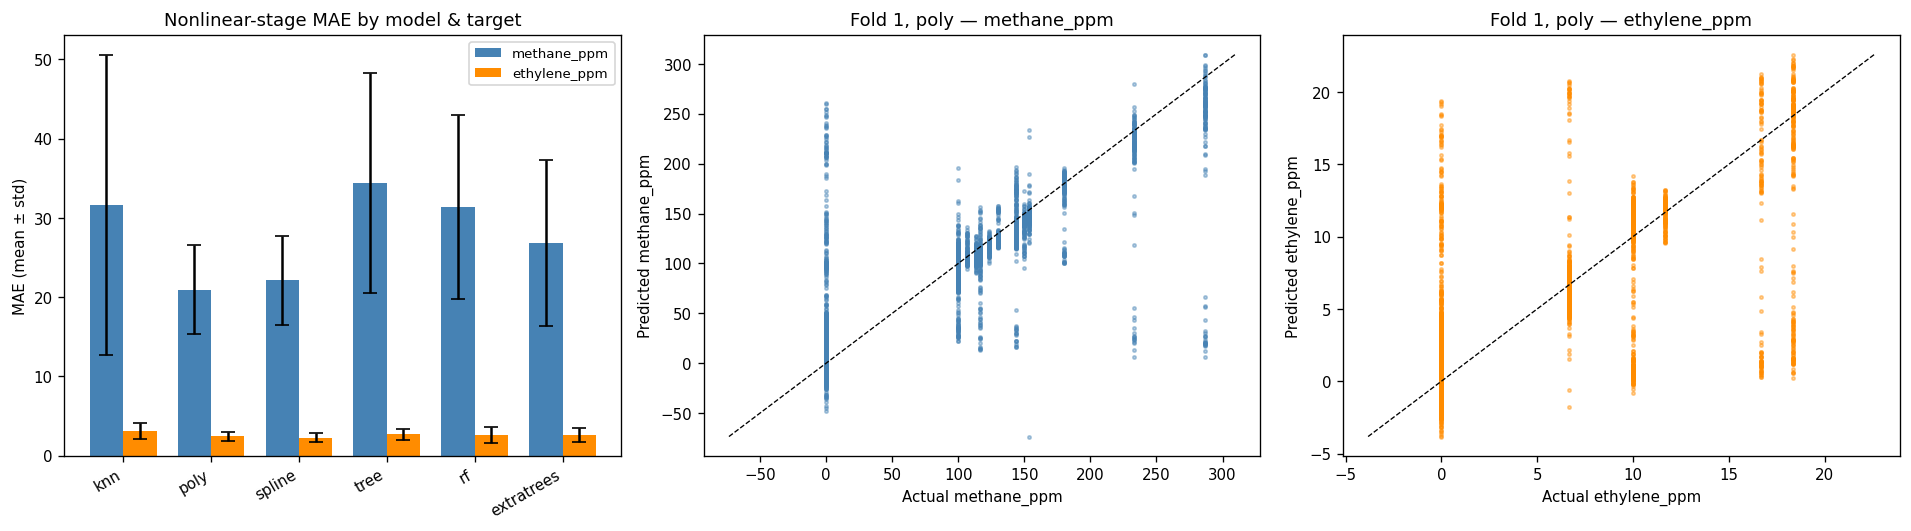

Saved: 08_nonlinear_models.png  (best nonlinear model by mean R²: poly)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
models = list(make_models().keys())
colors = {'methane_ppm': 'steelblue', 'ethylene_ppm': 'darkorange'}

# (a) MAE bars
ax = axes[0]
x = np.arange(len(models))
w = 0.38
for offset, target in zip((-w/2, w/2), TARGETS):
    means = [metrics_long[(metrics_long['model']==m)&(metrics_long['target']==target)]['mae'].mean() for m in models]
    stds  = [metrics_long[(metrics_long['model']==m)&(metrics_long['target']==target)]['mae'].std()  for m in models]
    ax.bar(x + offset, means, w, yerr=stds, capsize=4, label=target, color=colors[target])
ax.set_xticks(x); ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_ylabel('MAE (mean ± std)'); ax.set_title('Nonlinear-stage MAE by model & target')
ax.legend(fontsize=8)

# Pick best model by mean R² (pooled across folds & targets, scale-free)
best = metrics_long.groupby('model')['r2'].mean().idxmax()
art  = joblib.load(MODEL_DIR / f'fold_1_{best}.joblib')
va   = splits_df[(splits_df['fold']==1)&(splits_df['split']=='val')].iloc[0]
X_va = df[SENSORS].iloc[va['start_idx']:va['end_idx']].to_numpy()
y_va = df[TARGETS].iloc[va['start_idx']:va['end_idx']].to_numpy()
y_pred = art['model'].predict(art['scaler'].transform(X_va))

n_plot = min(5000, len(y_va))
samp = np.random.default_rng(SEED).choice(len(y_va), n_plot, replace=False)

for ax, t_idx, target in zip(axes[1:], (0, 1), TARGETS):
    a = y_va[samp, t_idx]; p = y_pred[samp, t_idx]
    ax.scatter(a, p, s=4, alpha=0.4, color=colors[target])
    lo = float(min(a.min(), p.min())); hi = float(max(a.max(), p.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
    ax.set_xlabel(f'Actual {target}'); ax.set_ylabel(f'Predicted {target}')
    ax.set_title(f'Fold 1, {best} — {target}')

plt.tight_layout()
plt.savefig(FIG_DIR / '08_nonlinear_models.png', bbox_inches='tight')
plt.show()
print(f'Saved: 08_nonlinear_models.png  (best nonlinear model by mean R²: {best})')

## 7. Save Memo

In [8]:
def df_to_md(t):
    header = '| ' + ' | '.join(str(c) for c in t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |' for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

ranking = (metrics_long.groupby('model')[['mae', 'rmse', 'r2']]
           .mean().round(4).reset_index()
           .sort_values('r2', ascending=False))
best_model = ranking.iloc[0]['model']

lines = [
    '# 08 - Nonlinear Models (untuned)',
    '',
    '**Date:** 2026-05-23',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Splits artifact:** {SPLITS_PATH.as_posix()}',
    f'**Subset artifact:** {SUBSET_PATH.as_posix()}',
    '',
    '---',
    '',
    '## Protocol',
    '- Per fold: training set = `train_range ∩ fair_subset` (~395k rows). Validation = full val slice (untouched).',
    '- Fresh `RobustScaler` fit on each fold\'s training intersection; applied to train and val.',
    '- All models native multi-output (poly/spline via LinearRegression on expanded basis).',
    '- 5 folds × 6 models × 2 targets = 60 metric records.',
    '',
    '## Roster',
    '- `knn`        – `KNeighborsRegressor(n_neighbors=15)`, local nonlinear.',
    '- `poly`       – `PolynomialFeatures(degree=2) → LinearRegression`, ~153 features.',
    '- `spline`     – `SplineTransformer(n_knots=5, degree=3) → LinearRegression`, ~112 features.',
    '- `tree`       – `DecisionTreeRegressor(max_depth=12)`, capped depth.',
    '- `rf`         – `RandomForestRegressor(n_estimators=200, min_samples_leaf=20)`.',
    '- `extratrees` – `ExtraTreesRegressor(n_estimators=200, min_samples_leaf=20)`.',
    '',
    '## Ranking (mean across folds & targets, sorted by R² descending)',
    '',
    'Note: MAE/RMSE pool across two targets with different scales; R² is the scale-free comparator.',
    '',
    df_to_md(ranking),
    '',
    f'**Best nonlinear model:** `{best_model}`',
    '',
    '## Summary (mean ± std across 5 folds, per target)',
    '',
    df_to_md(summary),
    '',
    '## Artifacts',
    f'- Per-fold metrics: `{long_path.as_posix()}`',
    f'- Summary metrics:  `{summary_path.as_posix()}`',
    f'- Fitted models:    `{MODEL_DIR.as_posix()}/fold_{{k}}_{{name}}.joblib` (30 files)',
    f'- Figure:           `{(FIG_DIR / "08_nonlinear_models.png").as_posix()}`',
    '',
    '## Next step',
    'Notebook `09_boosted_models.ipynb` (pending approval): GradientBoosting, HistGradientBoosting, XGBoost/LightGBM/CatBoost under the same protocol.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\08_nonlinear_models.md
